In [1]:
import gpjax as gpx

# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import (
    Float,
    install_import_hook,
)
import matplotlib as mpl
import matplotlib.pyplot as plt
import optax as ox
import pandas as pd
from sklearn.preprocessing import StandardScaler

from gpjax.parameters import Static
from gpjax.typing import Array

import matplotlib.pyplot as plt
plt.style.use('default')  # or 'ggplot', 'seaborn', etc.

config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx


key = jr.key(42)

# set the default style for plotting
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

c:\Users\jimvo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(200, 1) <class 'jaxlib.xla_extension.ArrayImpl'>
jeyt () <class 'jax._src.prng.PRNGKeyArray'>
(10, 200) <class 'jaxlib.xla_extension.ArrayImpl'> [[ 0.6831916   0.63668577  0.74450394 ...  0.64321251  0.59134871
   0.44700223]
 [-0.24722422 -0.43248955 -0.71627757 ... -0.17990245 -0.03661096
   0.03480669]
 [ 1.17953638  1.03631108  1.00909443 ...  0.19086487 -0.0349653
  -0.17067541]
 ...
 [-1.12144959 -0.83773075 -1.17517663 ...  0.0337844   0.05362539
  -0.17068089]
 [-0.39305848 -0.64438706 -0.68254475 ... -0.21526191 -0.31159197
  -0.41793412]
 [ 1.5027464   1.36016512  1.35363991 ... -0.20771744 -0.11352707
  -0.14150784]]
(200, 1) <class 'jaxlib.xla_extension.ArrayImpl'>
jeyt () <class 'jax._src.prng.PRNGKeyArray'>
(10, 200) <class 'jaxlib.xla_extension.ArrayImpl'> [[ 0.6831916   0.67672938  0.67871393 ...  0.78054501  0.77568979
   0.7591728 ]
 [-0.24722422 -0.2877637  -0.34760176 ... -0.96899766 -0.89135909
  -0.81123104]
 [ 1.17953638  1.15502702  1.12951141 ...  0.72618464  

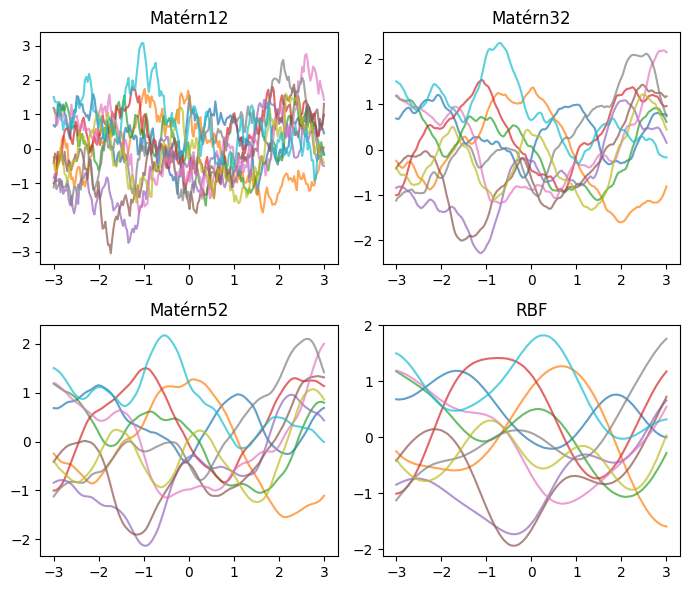

: 

In [ ]:
kernels = [
    gpx.kernels.Matern12(),
    gpx.kernels.Matern32(),
    gpx.kernels.Matern52(),
    gpx.kernels.RBF(),
]
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(7, 6), tight_layout=True)

x = jnp.linspace(-3.0, 3.0, num=200).reshape(-1, 1)

meanf = gpx.mean_functions.Zero()
key = jr.key(66)

for k, ax in zip(kernels, axes.ravel(), strict=False):
    prior = gpx.gps.Prior(mean_function=meanf, kernel=k)
    
    print(x.shape, type(x))
    rv = prior(x)
    print("jeyt", key.shape, type(key))
    y = rv.sample(key=key, sample_shape=(10,))
    print(y.shape, type(y), y)
    ax.plot(x, y.T, alpha=0.7)
    ax.set_title(k.name)